In [34]:
import pickle 
import ROOT
import numpy as np
import hist
import matplotlib.pyplot as plt
import mplhep as hep
from unfold_utils.integrate_and_rebin import rebin_hist
hep.style.use("CMS")  # Use CMS style for plots
closure = False
groomed = True

In [35]:
# load pickled datasets (pickle already imported in another cell)
paths = {
    "data1": "ROOT_files/pythia_ht_LO_output_no_syst.pkl",
    #"data2": "ROOT_files/herwig_ht_LO_output_no_syst.pkl",
    "data2": "ROOT_files/powheg_output_no_syst.pkl",
    "data3": "ROOT_files/data_all.pkl",
}

for name, p in paths.items():
    try:
        with open(p, "rb") as f:
            globals()[name] = pickle.load(f)
    except FileNotFoundError:
        raise FileNotFoundError(f"Could not find file: {p}")
    except Exception as e:
        raise RuntimeError(f"Failed to load {p}: {e}")

# quick sanity print
print("Loaded:", ", ".join(f"{n} (type={type(globals()[n]).__name__})" for n in paths))

Loaded: data1 (type=dict_accumulator), data2 (type=dict_accumulator), data3 (type=dict)


In [36]:
data2['ptjet_mjet_u_reco']

Hist(
  StrCategory(['MC_UL18NanoAODv9'], name='dataset'),
  StrCategory(['mm'], growth=True, name='channel', label='Channel'),
  Variable([0, 200, 290, 400, 13000], name='ptreco', label='$p_{T,RECO}$ (GeV)'),
  Variable(array([   0.,    5.,   10.,   20.,   30.,   40.,   50.,   60.,   70.,
         80.,   90.,  100.,  110.,  120.,  130.,  140.,  150.,  160.,
        170.,  180.,  190.,  200., 1000.]), name='mreco', label='$m_{RECO}$ (GeV)'),
  StrCategory(['nominal'], growth=True, name='systematic', label='Systematic Uncertainty'),
  storage=Weight()) # Sum: WeightedSum(value=8.21621e-05, variance=5.77547e-14)

In [37]:
[{'systematic':'nominal'}]

[{'systematic': 'nominal'}]

In [38]:
mass_edges_reco = [   0.,    5.,   10.,   20.,   30.,   40.,   50.,   60.,   70.,
         80.,   90.,  100.,  110.,  120.,  130.,  140.,  150.,  160.,
        170.,  180.,  190.,  200., 1000.]
mass_edges_gen = [0, 10, 30, 50, 70, 90, 110, 130, 150, 170, 200, 1000]

In [39]:
data3['ptjet_mjet_u_reco'].axes[1]

Variable(array([   0.,    5.,   10.,   20.,   30.,   40.,   50.,   60.,   70.,
         80.,   90.,  100.,  110.,  120.,  130.,  140.,  150.,  160.,
        170.,  180.,  190.,  200., 1000.]), name='mreco', label='$m_{RECO}$ (GeV)')

In [40]:
rebin_factor = 4
rebin_factor_gen  = 8
groomed = True
if groomed:
    pythia4d = data1['response_matrix_g'].project('ptgen', 'mgen', 'ptreco', 'mreco')[:, hist.rebin(rebin_factor_gen), :, hist.rebin(rebin_factor)]
    herwig4d = data2['response_matrix_g'].project('ptgen', 'mgen', 'ptreco', 'mreco')[:, hist.rebin(rebin_factor_gen), :, hist.rebin(rebin_factor)]
    pythia2d = data1['response_matrix_g'].project('ptreco', 'mreco')[:, hist.rebin(rebin_factor)]
    herwig2d = data1['response_matrix_g'].project('ptreco', 'mreco')[:, hist.rebin(rebin_factor)]
    data2d = data3['ptjet_mjet_g_reco'].project('ptreco', 'mreco')[:, hist.rebin(rebin_factor)]


    mass_start = 0
    mass_end = 210

    pythia4d = pythia4d[:, hist.loc(mass_start):hist.loc(mass_end), :, hist.loc(mass_start):hist.loc(mass_end)]
    herwig4d = herwig4d[:, hist.loc(mass_start):hist.loc(mass_end), :, hist.loc(mass_start):hist.loc(mass_end)]
    pythia2d = pythia2d[:, hist.loc(mass_start):hist.loc(mass_end)]
    herwig2d = herwig2d[:, hist.loc(mass_start):hist.loc(mass_end)]
if not groomed:
    pythia4d = data1['response_matrix_u'].project('ptgen', 'mgen', 'ptreco', 'mreco')[:, hist.rebin(rebin_factor_gen), :, hist.rebin(rebin_factor)]
    herwig4d = data2['response_matrix_u'].project('ptgen', 'mgen', 'ptreco', 'mreco')[:, hist.rebin(rebin_factor_gen), :, hist.rebin(rebin_factor)]
    pythia2d = data1['response_matrix_u'].project('ptreco', 'mreco')[:, hist.rebin(rebin_factor)]
    herwig2d = data2['response_matrix_u'].project('ptreco', 'mreco')[:, hist.rebin(rebin_factor)]
    data2d = data3['ptjet_mjet_u_reco'].project('ptreco', 'mreco')[:, hist.rebin(rebin_factor)]

    mass_start = 0
    mass_end = 210

    pythia4d = pythia4d[:, hist.loc(mass_start):hist.loc(mass_end), :, hist.loc(mass_start):hist.loc(mass_end)]
    herwig4d = herwig4d[:, hist.loc(mass_start):hist.loc(mass_end), :, hist.loc(mass_start):hist.loc(mass_end)]
    pythia2d = pythia2d[:, hist.loc(mass_start):hist.loc(mass_end)]
    herwig2d = herwig2d[:, hist.loc(mass_start):hist.loc(mass_end)]

# pythia4d = data1['response_matrix_u'].project('ptgen', 'mgen', 'ptreco', 'mreco')
# herwig4d = data2['response_matrix_u'].project('ptgen', 'mgen', 'ptreco', 'mreco')
# pythia2d = data1['response_matrix_u'].project('ptreco', 'mreco')
# herwig2d = data1['response_matrix_u'].project('ptreco', 'mreco')

In [41]:
rebin_factor = 5
rebin_factor_gen  = 10
pt_slices = [(0,200.), (200.,290.), (290.,400.), (400.,13000.)]
if groomed:
    pythia4d = data1['response_matrix_g'][{'systematic':'nominal'}].project('ptgen', 'mgen', 'ptreco', 'mreco')
    herwig4d = data2['response_matrix_g'][{'systematic':'nominal'}].project('ptgen', 'mgen', 'ptreco', 'mreco')
    pythia2d = data1['response_matrix_g'][{'systematic':'nominal'}].project('ptreco', 'mreco')
    herwig2d = data1['response_matrix_g'][{'systematic':'nominal'}].project('ptreco', 'mreco')
    data2d = data3['ptjet_mjet_g_reco'][{'systematic':'nominal'}].project('ptreco', 'mreco')
    pythia_gen2d = data1['ptjet_mjet_g_gen'][{'systematic':'nominal'}].project('ptgen', 'mgen')
    herwig_gen2d = data2['ptjet_mjet_g_gen'][{'systematic':'nominal'}].project('ptgen', 'mgen')

    pythia4d = rebin_hist(pythia4d, 'mgen', mass_edges_gen)
    pythia4d = rebin_hist(pythia4d, 'mreco', mass_edges_reco)
    herwig4d = rebin_hist(herwig4d, 'mgen', mass_edges_gen)
    herwig4d = rebin_hist(herwig4d, 'mreco', mass_edges_reco)
    pythia2d = rebin_hist(pythia2d, 'mreco', mass_edges_reco)
    herwig2d = rebin_hist(herwig2d, 'mreco', mass_edges_reco)
    data2d = rebin_hist(data2d, 'mreco', mass_edges_reco)
    pythia_gen2d = rebin_hist(pythia_gen2d, 'mgen', mass_edges_gen)
    herwig_gen2d = rebin_hist(herwig_gen2d, 'mgen', mass_edges_gen)

    acceptance = pythia4d.values().sum(axis = (2,3)).flatten() / pythia_gen2d.values().flatten()
    # # mass_start = 0
    # # mass_end = 200

    # pythia4d = pythia4d[:, hist.loc(mass_start):hist.loc(mass_end), :, hist.loc(mass_start):hist.loc(mass_end)]
    # herwig4d = herwig4d[:, hist.loc(mass_start):hist.loc(mass_end), :, hist.loc(mass_start):hist.loc(mass_end)]
    # pythia2d = pythia2d[:, hist.loc(mass_start):hist.loc(mass_end)]
    # herwig2d = herwig2d[:, hist.loc(mass_start):hist.loc(mass_end)]
    # pythia_gen2d = pythia_gen2d[:, hist.loc(mass_start):hist.loc(mass_end)]
    # herwig_gen2d = herwig_gen2d[:, hist.loc(mass_start):hist.loc(mass_end)]

if not groomed:
    pythia4d = data1['response_matrix_u'][{'systematic':'nominal'}].project('ptgen', 'mgen', 'ptreco', 'mreco')
    herwig4d = data2['response_matrix_u'][{'systematic':'nominal'}].project('ptgen', 'mgen', 'ptreco', 'mreco')
    pythia2d = data1['response_matrix_u'][{'systematic':'nominal'}].project('ptreco', 'mreco')
    herwig2d = data1['response_matrix_u'][{'systematic':'nominal'}].project('ptreco', 'mreco')
    data2d = data3['ptjet_mjet_u_reco'][{'systematic':'nominal'}].project('ptreco', 'mreco')
    pythia_gen2d = data1['ptjet_mjet_u_gen'][{'systematic':'nominal'}].project('ptgen', 'mgen')
    herwig_gen2d = data2['ptjet_mjet_u_gen'][{'systematic':'nominal'}].project('ptgen', 'mgen')

    pythia4d = rebin_hist(pythia4d, 'mgen', mass_edges_gen)
    pythia4d = rebin_hist(pythia4d, 'mreco', mass_edges_reco)
    herwig4d = rebin_hist(herwig4d, 'mgen', mass_edges_gen)
    herwig4d = rebin_hist(herwig4d, 'mreco', mass_edges_reco)
    pythia2d = rebin_hist(pythia2d, 'mreco', mass_edges_reco)
    herwig2d = rebin_hist(herwig2d, 'mreco', mass_edges_reco)
    data2d = rebin_hist(data2d, 'mreco', mass_edges_reco)
    pythia_gen2d = rebin_hist(pythia_gen2d, 'mgen', mass_edges_gen)
    herwig_gen2d = rebin_hist(herwig_gen2d, 'mgen', mass_edges_gen)

    

    acceptance = pythia4d.values().sum(axis = (2,3)).flatten() / pythia_gen2d.values().flatten()
# pythia4d = data1['response_matrix_u'].project('ptgen', 'mgen', 'ptreco', 'mreco')
# herwig4d = data2['response_matrix_u'].project('ptgen', 'mgen', 'ptreco', 'mreco')
# pythia2d = data1['response_matrix_u'].project('ptreco', 'mreco')
# herwig2d = data1['response_matrix_u'].project('ptreco', 'mreco')

/home/aritra/ws/unfold/unfold_utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/aritra/ws/unfold/unfold_utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():
/tmp/ipykernel_32414/3755327593.py:23: RuntimeWarning: invalid value encountered in divide
  acceptance = pythia4d.values().sum(axis = (2,3)).flatten() / pythia_gen2d.values().flatten()


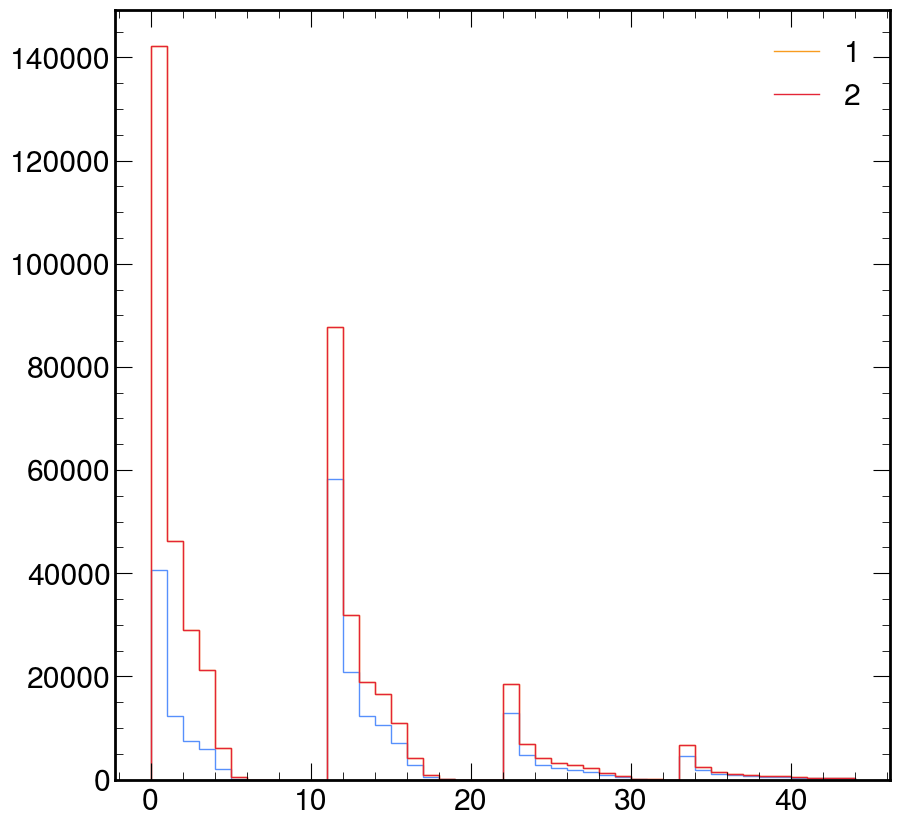

In [42]:
plt.stairs(pythia4d.values().sum(axis=(2,3)).flatten())
plt.stairs(pythia_gen2d.values().flatten(), label = '1')
plt.stairs(pythia4d.values().sum(axis=(2,3)).flatten()/acceptance.flatten(), label = '2')
plt.legend()

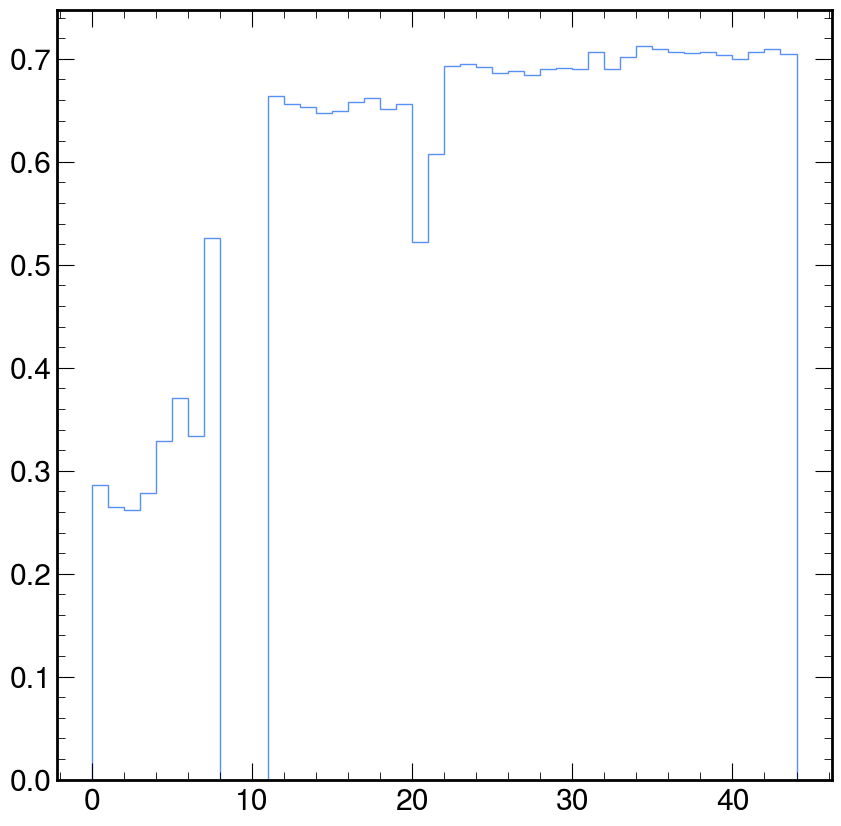

In [43]:
plt.stairs(acceptance.flatten())

In [44]:
pnp = pythia4d.values().reshape(pythia4d.values().shape[0]*pythia4d.values().shape[1], pythia4d.values().shape[2]*pythia4d.values().shape[3])
hnp = pythia4d.values().reshape(pythia4d.values().shape[0]*pythia4d.values().shape[1], pythia4d.values().shape[2]*pythia4d.values().shape[3])

/tmp/ipykernel_32414/790883932.py:2: RuntimeWarning: invalid value encountered in divide
  pnp_norm = pnp / np.sum(pnp, axis=1, keepdims=True)


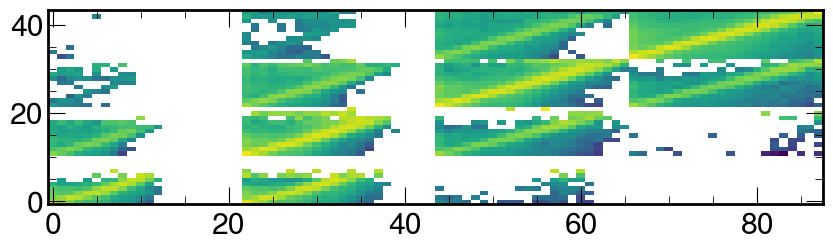

In [45]:
hep.style.use("CMS")
pnp_norm = pnp / np.sum(pnp, axis=1, keepdims=True)
plt.imshow(pnp_norm, origin = 'lower', aspect = rebin_factor/rebin_factor_gen, norm = 'log')

In [46]:
mass_edges_reco = pythia4d.axes['mreco'].edges.tolist()
mass_edges_gen = pythia4d.axes['mgen'].edges.tolist()


In [47]:
#!/usr/bin/env python3
import random
from array import array
import ROOT as r
import numpy as _np
r.gROOT.SetBatch(True)
random.seed(42)

# ----------------------------
# 1) Define pT slices and mass edges (edit for your analysis)
# ----------------------------
pt_slices = [(0,200.), (200.,290.), (290.,400.), (400.,13000.)]
mreco_edges_pt = [
    mass_edges_reco,  # slice 0
    mass_edges_reco,          # slice 1
    mass_edges_reco,                   # slice 2
    mass_edges_reco,
]
mgen_edges_pt = [
    mass_edges_gen,  # slice 0
    mass_edges_gen,          # slice 1
    mass_edges_gen,                   # slice 2
    mass_edges_gen,   
]
assert len(pt_slices) == len(mreco_edges_pt)

# resolutions (toy)
rel_pt_res = [0.10, 0.08, 0.06]
abs_m_res  = [4.0,  5.0,  6.0]

def find_slice(pt):
    for i,(lo,hi) in enumerate(pt_slices):
        if lo <= pt < hi: return i
    return None

def sample_truth_pt():
    # ~ pT^{-4} between 200 and 1000
    n, pmin, pmax = 4.0, 200.0, 1000.0
    u = random.random()
    a, b = pmin**(1-n), pmax**(1-n)
    return (a + u*(b-a))**(1/(1-n))

def sample_truth_mass(i):
    lo, hi = mass_edges[i][0], mass_edges[i][-1]
    mode, scale = [14.,22.,30.][i], [8.,10.,12.][i]
    for _ in range(1000):
        m = max(0.0, random.expovariate(1.0/scale)) + 0.5*mode
        if lo <= m < hi: return m
    return min(max(mode, lo), hi-1e-6)

def smear_pt(pt,i):   return max(0.0, random.gauss(pt, rel_pt_res[i]*pt))
def smear_m(m,i):     return max(0.0, random.gauss(m,  abs_m_res[i]))

# ----------------------------
# 2) Build binning trees with named nodes
#    truth:  root("truth") -> signal -> pt0,pt1,pt2 (each has "mass" axis)
#    reco :  root("reco")  -> primary -> pt0,pt1,pt2 (each has "mass" axis)
# ----------------------------
truth_root = r.TUnfoldBinning("truth")
reco_root  = r.TUnfoldBinning("reco")

truth_signal = truth_root.AddBinning("signal")
reco_primary = reco_root .AddBinning("primary")

truth_nodes, reco_nodes = [], []
# use separate mass-edge lists for truth (gen) and reco; keep `mass_edges` pointing to gen for sample_truth_mass
mass_edges = mgen_edges_pt

for i in range(len(pt_slices)):
    a_gen  = array('d', mgen_edges_pt[i])
    a_reco = array('d', mreco_edges_pt[i])
    tnode = truth_signal.AddBinning(f"pt{i}")
    rnode = reco_primary.AddBinning(f"pt{i}")
    # 1D mass axis inside each slice; exclude under/overflow bins here
    tnode.AddAxis("mass", len(mgen_edges_pt[i]) - 1, a_gen,  False, False)
    rnode.AddAxis("mass", len(mreco_edges_pt[i]) - 1, a_reco, False, False)
    truth_nodes.append(tnode)
    reco_nodes .append(rnode)

# ----------------------------
# 3) Book histograms consistent with the binning
# ----------------------------
hRecoData   = reco_root .CreateHistogram("hRecoData")    # TH1D over global reco bins
hTruthPrior = truth_root.CreateHistogram("hTruthPrior")  # TH1D over global truth bins
hResponse   = r.TUnfoldBinning.CreateHistogramOfMigrations( truth_root, reco_root, "hResponse")  # TH2D (x=reco, y=truth)

# ----------------------------
# 4) Fill toy MC for response + prior
# ----------------------------
n_mc = 200_000
# fill hResponse from the 4D hist pythia4d (axes: ptgen, mgen, ptreco, mreco)

ptgen_centres = pythia4d.axes['ptgen'].centers
mgen_centres  = pythia4d.axes['mgen'].centers
ptreco_centres= pythia4d.axes['ptreco'].centers
mreco_centres = pythia4d.axes['mreco'].centers
# ptgen_centres = np.array([50, 250, 300, 450])
# ptreco_centres= np.array([50, 250, 300, 450])
# get values & variances (numpy ndarray with axis order ptgen, mgen, ptreco, mreco)
vals = pythia4d.values(flow = False)
vars_ = pythia4d.variances(flow = False)

for i_ptg, ptg in enumerate(ptgen_centres):
    ig = find_slice(ptg)
    if ig is None: continue
    for i_mg, mg in enumerate(mgen_centres):
        # truth global bin for this pt slice & mass centre
        bT = truth_nodes[ig].GetGlobalBinNumber(array('d', [mg]))
        if bT <= 0: continue

        for i_ptr, ptr in enumerate(ptreco_centres):
            ir = find_slice(ptr)
            if ir is None: continue

            for i_mr, mr in enumerate(mreco_centres):
                val = float(vals[i_ptg, i_mg, i_ptr, i_mr])
                var = float(vars_[i_ptg, i_mg, i_ptr, i_mr])
                if val == 0.0 and var == 0.0:
                    continue

                bR = reco_nodes[ir].GetGlobalBinNumber(array('d', [mr]))
                if bR <= 0: continue

                # try the (ix,iy) overload first, fall back to global bin number if necessary
                try:
                    hResponse.SetBinContent(bT, bR, val)
                    if var > 0.0:
                        hResponse.SetBinError(bT, bR, _np.sqrt(var))
                except TypeError:
                    gbin = hResponse.GetBin(bT, bR)  # global TH2 bin
                    hResponse.SetBinContent(gbin, val)
                    if var > 0.0:
                        hResponse.SetBinError(gbin, _np.sqrt(var))

# ----------------------------
# 5) Fill toy RECO data
# ----------------------------
# fill hRecoData from pythia2d (binned ptreco x mreco)
ptreco_centres = pythia2d.axes['ptreco'].centers
mreco_centres  = pythia2d.axes['mreco'].centers
ptreco_centres= np.array([50, 250, 300, 450])

vals  = herwig4d.values().sum(axis=(0,1))  # sum out truth axes -> ptreco x mreco
vars_ = herwig4d.variances().sum(axis=(0,1))


vals2  = herwig4d.values().sum(axis=(0,1))  # sum out truth axes -> ptreco x mreco
vars2_ = herwig4d.variances().sum(axis=(0,1))

gen_vals  = pythia_gen2d.values()  # sum out truth axes -> ptreco x mreco
gen_vars_ = pythia_gen2d.variances()

gen_vals2  = herwig_gen2d.values()  # sum out truth axes -> ptreco x mreco
gen_vars2_ = herwig_gen2d.variances()


if closure:
    vals  = pythia4d.values().sum(axis=(0,1))  # sum out truth axes -> ptreco x mreco
    vars_ = pythia4d.variances().sum(axis=(0,1))
else:
    vals  = herwig4d.values().sum(axis=(0,1))  # sum out truth axes -> ptreco x mreco
    vars_ = herwig4d.variances().sum(axis=(0,1))
    vals = data2d.values()
    vars_ = data2d.variances()
# hRecoData2 = hRecoData.Clone("hRecoData2")
# hRecoData2.Reset()

for i_ptr, ptr in enumerate(ptreco_centres):
    ir = find_slice(ptr)
    if ir is None:
        continue
    for i_mr, mr in enumerate(mreco_centres):
        val = float(vals[i_ptr, i_mr])
        var = float(vars_[i_ptr, i_mr])

        if val == 0.0 and var == 0.0:
            continue
        bR = reco_nodes[ir].GetGlobalBinNumber(array('d', [mr]))
        if bR <= 0:
            continue
        hRecoData.SetBinContent(bR, val)
        if var > 0.0:
            hRecoData.SetBinError(bR, _np.sqrt(var))

# ----------------------------
# 6) Construct TUnfoldDensity with full argument list
#     - EHistMap: kHistMapOutputHoriz  (x=reco, y=truth)
#     - Regularise only the 'signal' truth distribution
#     - Axis steering: *[UOB]  (drop under/overflow; bin-width aware derivatives)
# ----------------------------
unfold = r.TUnfoldDensity(
    hResponse,
    r.TUnfold.kHistMapOutputHoriz,          # mapping of TH2 axes
    r.TUnfold.kRegModeDerivative,            # curvature regularisation
    r.TUnfold.kEConstraintArea,             # one global area constraint
    r.TUnfoldDensity.kDensityModeBinWidthAndUser,  # bin-width aware scaling
    truth_root,                              # output (truth) binning tree
    reco_root,                               # input  (reco)  binning tree
    "signal",                                # regularisationDistributionName
    "*[UOB]"                                 # regularisationAxisSteering
)

# Provide input and bias
unfold.SetInput(hRecoData, 1.0)
#unfold.SetBias(hTruthPrior)

unfold.DoUnfold(0.000)

# ----------------------------
# 7) Retrieve outputs & diagnostics
# ----------------------------



0.8906340328274354

Warning in <TROOT::Append>: Replacing existing TH1: hRecoData (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hTruthPrior (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hResponse (Potential memory leak).
Info in <TUnfold::SetConstraint>: fConstraint=1
Warning in <TUnfold::TUnfold>: 5 output bins do not depend on the input data  0 9-11 45
Info in <TUnfold::TUnfold>: 88 input bins and 41 output bins
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #0
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #9 (pt0:mass[150,170])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #10 (pt0:mass[170,200])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #11 (pt0:mass[200,1e+03])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #45
Info in <TUnfoldDensity::RegularizeOneDistribution>: regularizing signal regMode=2 densityMode=3 axisSteering=*[UOB]
Warning in <TUnfoldDensity::SetInput>: 13/88 input bins have zero er

In [48]:

# np.linalg.cond(pnp_norm)

In [49]:
c = r.TCanvas('c','c',800,600)
hRecoData.Draw('E')
y = hResponse.ProjectionY()

y.Draw('same')
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


In [50]:
# c2 = r.TCanvas('c2','c2',800,600)
# hRecoData.Draw('E')
# y = hResponse.ProjectionY()

# y.Draw('same')
# c2.Draw()

In [51]:
output = unfold.GetOutput('h')
rp = unfold.GetProbabilityMatrix('rp')
c_rp = r.TCanvas('c_rp', 'rp', 900, 700)
c_rp.SetRightMargin(0.18)
rp.SetTitle('Response probability matrix (rp);reco global bin;truth global bin')
rp.SetStats(0)
rp.Draw('COLZ')
c_rp.SetLogz()
c_rp.Draw()

Warning in <TUnfoldBinning::CreateHistogram>: Original binning can not be represented as THxx
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: rp (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_rp


In [52]:
c1 = r.TCanvas('c','c',800,600)

y = hResponse.ProjectionX()
output.SetLineColor(r.kRed)
output.Draw('same')
y.Draw('same')
c1.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


Mass edges: [0.0, 10.0, 30.0, 50.0, 70.0, 90.0, 110.0, 130.0, 150.0, 170.0, 200.0, 1000.0]
Sum values per pt slice: [np.float64(149892.5509587978), np.float64(204287.25315996876), np.float64(58518.8517974657), np.float64(22346.975091941218)]
Extracted 44 bins: arrays vals2 (values), vals2_err (errors), vals2_centers, vals2_edges


/tmp/ipykernel_32414/3420202877.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


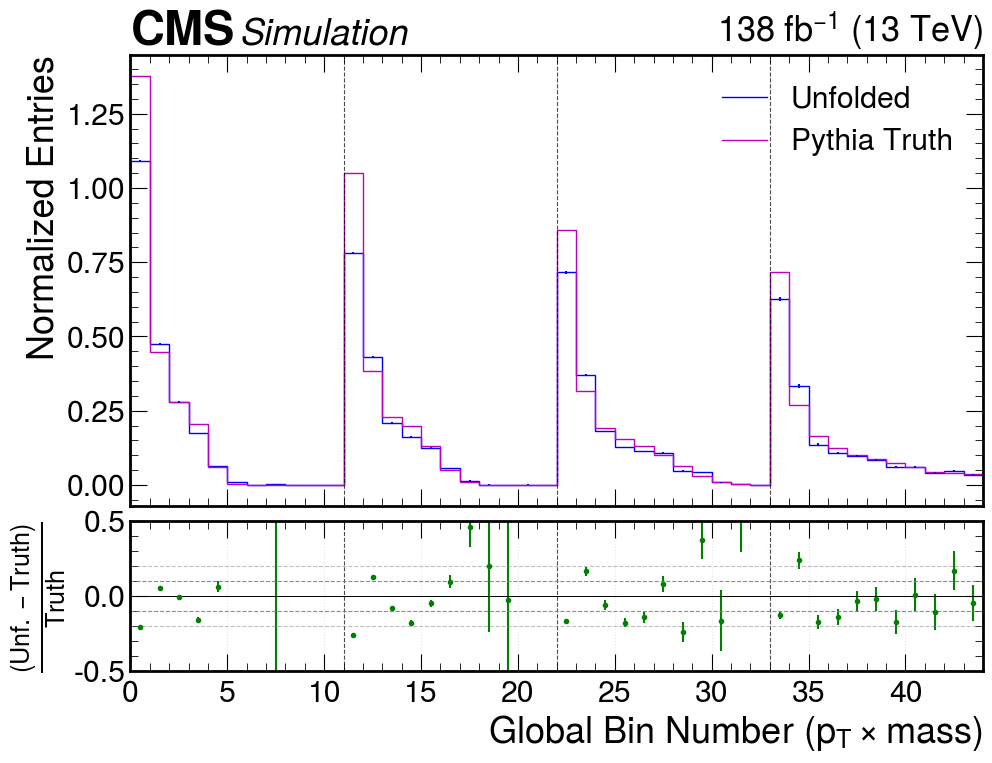

In [56]:
# extract TH1D 'output' into numpy arrays
if 'output' not in globals():
    raise NameError("Histogram 'output' not found in globals()")

nbins = int(output.GetNbinsX())

edges = np.array([output.GetXaxis().GetBinLowEdge(i) for i in range(1, nbins + 2)])
centers = np.array([output.GetXaxis().GetBinCenter(i) for i in range(1, nbins + 1)])
values = np.array([output.GetBinContent(i) for i in range(1, nbins + 1)])
values = np.where(acceptance.flatten() != 0, values/np.nan_to_num(acceptance.flatten(), nan=1.0), values)
errors = np.array([output.GetBinError(i) for i in range(1, nbins + 1)])
print("Mass edges:", mgen_edges_pt[0])

nbins_m = len(mgen_edges_pt[0]) - 1
sum_values = [np.sum(values[i*nbins_m +1 :(i+1)*nbins_m]) for i in range(len(pt_slices))]
print("Sum values per pt slice:", sum_values)
for i in range(len(pt_slices)):
    if sum_values[i] != 0:
        values[i*nbins_m:(i+1)*nbins_m] /= sum_values[i]
        errors[i*nbins_m:(i+1)*nbins_m] /= sum_values[i]
# convenience container
vals2 = values  # keep name requested by the notebook if desired
vals2_edges = edges
vals2_centers = centers
vals2_err = errors

print(f"Extracted {nbins} bins: arrays vals2 (values), vals2_err (errors), vals2_centers, vals2_edges")

# build a figure with shared x: main plot on top, ratio underneath
fig, (ax, axr) = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
    figsize=(11, 8)
)
# normalize gen_vals2 & gen_vars2_ per pt slice (matching above)
for i in range(len(gen_vals2)):
    s1 = np.sum(gen_vals[i][1:])  # skip overflow bin
    s2 = np.sum(gen_vals2[i][1:])  # skip underflow bin
    if s2 != 0:
        gen_vars2_[i] /= s2**2
        gen_vals2[i] /= s2
    if s1 != 0:
        gen_vars_[i] /= s1**2
        gen_vals[i] /= s1
# Top: unfolded vs truth
ax.stairs(vals2, label='Unfolded', color='b')
ax.errorbar(np.arange(vals2_centers.size) + 0.5, vals2, yerr=vals2_err, fmt='none', ecolor='b', capsize=0)
#ax.stairs(gen_vals2.flatten(), label="Herwig Truth", color='r')
ax.stairs(gen_vals.flatten(), label="Pythia Truth", color='m')
#ax.errorbar(np.arange(vals2_centers.size) + 0.5, gen_vals2.flatten(), yerr=np.sqrt(gen_vars2_.flatten()), fmt='none', ecolor='r', capsize=0)
ax.legend()
ax.set_ylabel("Normalized Entries")
ax.set_xlim(0, vals2_centers.size)
hep.cms.label(ax = ax, data=False, lumi=138)
# draw vertical separators between pt-slices every nbins_m bins
for k in range(1, len(pt_slices)):
    x = k * nbins_m 
    ax.axvline(x, color='k', linestyle='--', lw=0.8, alpha=0.7)
    axr.axvline(x, color='k', linestyle='--', lw=0.8, alpha=0.7)

# Bottom: ratio (U - T) / T with propagated errors (assuming uncorrelated)
denom = gen_vals.flatten()
mask = denom != 0
ratio = np.full_like(vals2, np.nan, dtype=float)
ratio_err = np.full_like(vals2, np.nan, dtype=float)

sigma_u2 = vals2_err**2
sigma_t2 = gen_vars2_.flatten()  # variances

ratio[mask] = (vals2[mask] - denom[mask]) / denom[mask]
# propagate error for U/T ≈ sqrt( var(U)/T^2 + var(T)*U^2/T^4 ), then ratio_err is same (since ratio = U/T - 1)
with np.errstate(divide='ignore', invalid='ignore'):
    ratio_err[mask] = np.sqrt( sigma_u2[mask] / denom[mask]**2 + sigma_t2[mask] * (vals2[mask]**2) / denom[mask]**4 )

axr.errorbar(np.arange(vals2_centers.size) + 0.5, ratio, yerr=ratio_err, fmt='o', markersize=3, capsize=0, color='g')
axr.axhline(0.0, color='k', lw=0.7)
axr.axhline(-0.1, color='gray', linestyle='--', lw=0.8, alpha=0.9)
axr.axhline(0.1,  color='gray', linestyle='--', lw=0.8, alpha=0.9)
axr.axhline(-0.2, color='gray', linestyle='--', lw=0.8, alpha=0.5)
axr.axhline(0.2,  color='gray', linestyle='--', lw=0.8, alpha=0.5)
axr.set_ylabel(r"$\frac{(Unf.-Truth)}{Truth}$")
axr.set_xlabel(r"Global Bin Number ($p_T \times \text{mass}$)")
axr.set_ylim(-0.5, 0.5)
axr.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_9321/61506201.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


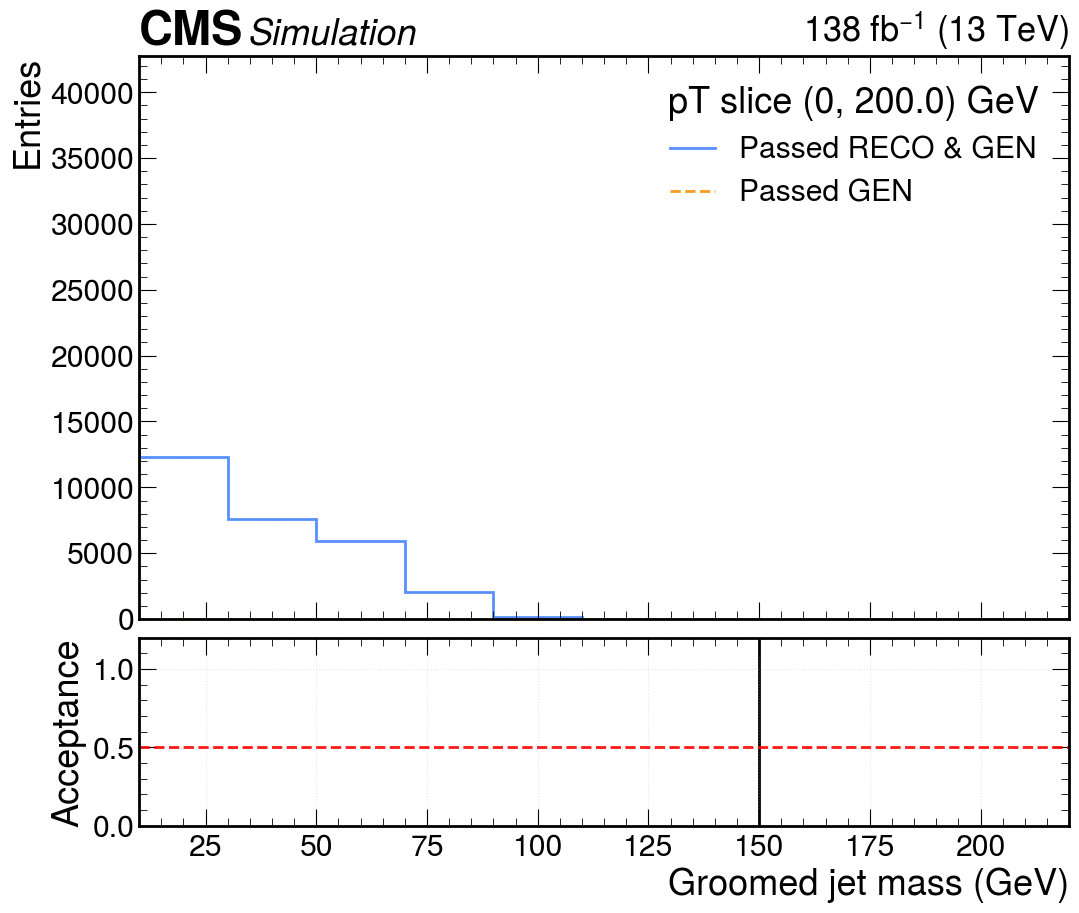

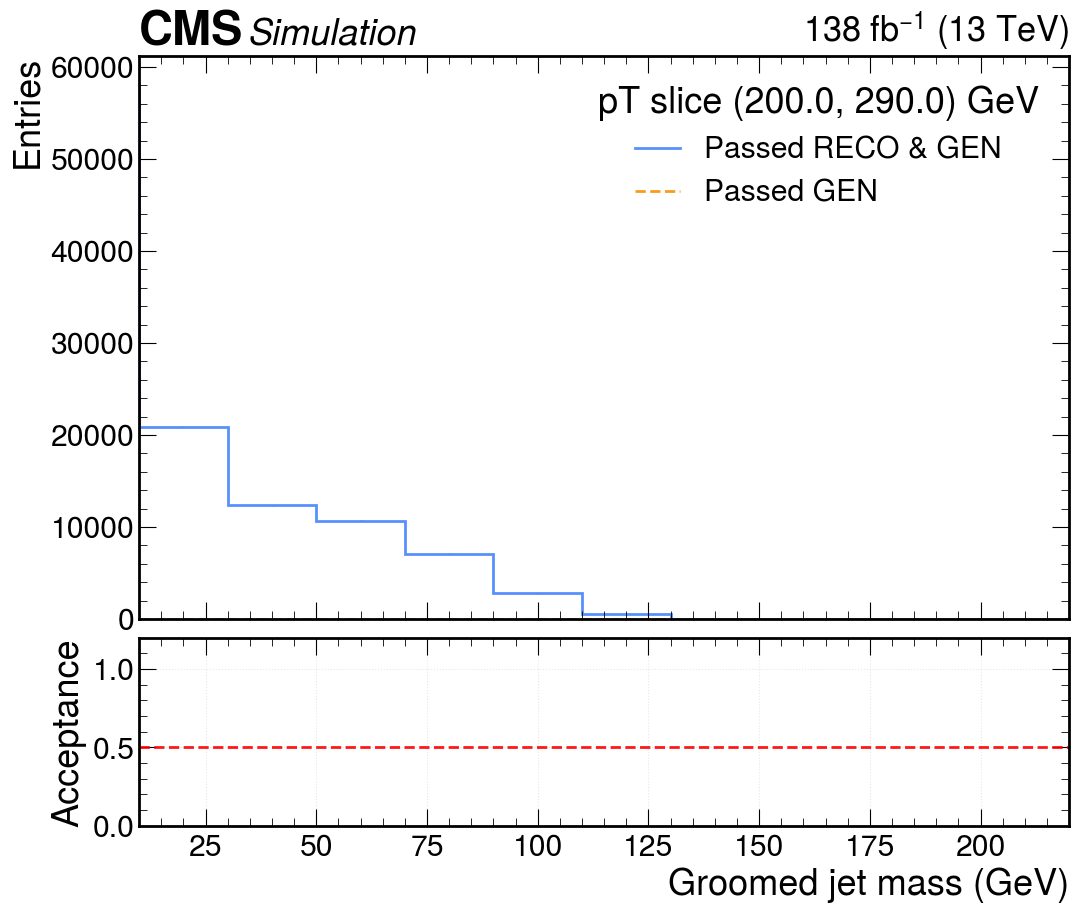

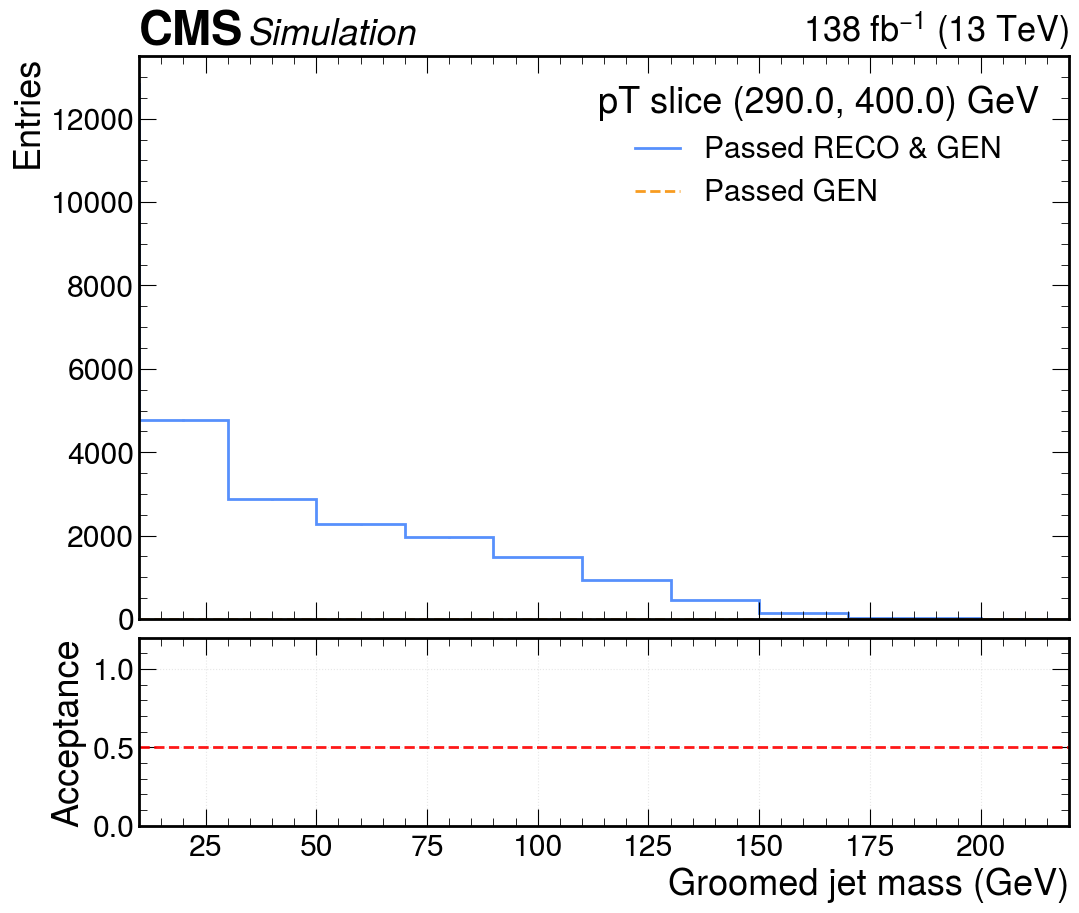

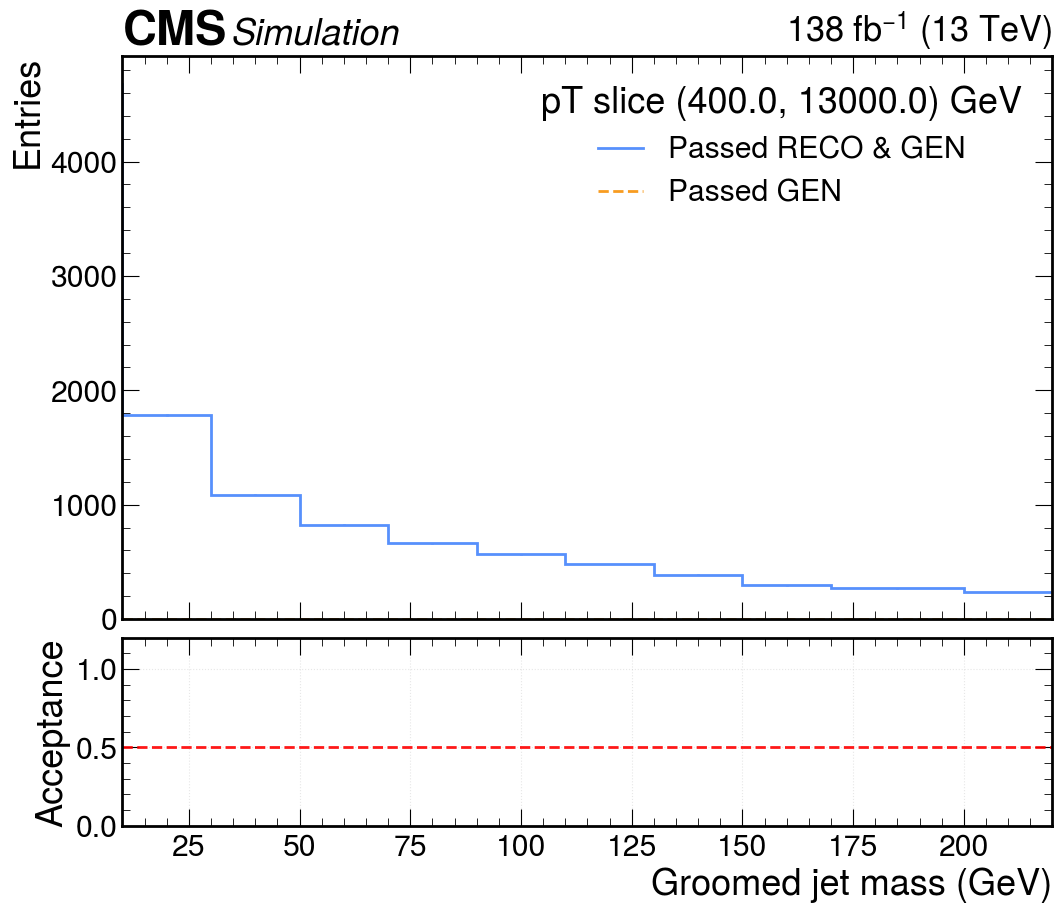

In [62]:
# split into 4 plots (one per pt slice), add errorbars and acceptance ratio underneath
nbins_m = len(mass_edges_gen) - 1
nbins_pt = len(pt_slices)

passed_rg = pythia4d.values().sum(axis=(2, 3)).flatten()        # passed RECO & GEN (global)
passed_rg_var = pythia4d.variances().sum(axis=(2, 3)).flatten()
passed_g = pythia_gen2d.values().flatten()                     # passed GEN (global)
passed_g_var = pythia_gen2d.variances().flatten()

xlabel = "Groomed jet mass (GeV)" if groomed else "Ungroomed jet mass (GeV)"
centers_all = mgen_centres  # gen mass bin centers (length nbins_m)

for i in range(nbins_pt):
    start = i * nbins_m
    end = start + nbins_m

    U = passed_rg[start:end].copy()
    Uerr = np.sqrt(passed_rg_var[start:end].copy())
    T = passed_g[start:end].copy()
    Terr = np.sqrt(passed_g_var[start:end].copy())

    edges_i = np.array(mgen_edges_pt[i])
    centers_i = centers_all

    fig, (ax, axr) = plt.subplots(
        2, 1, sharex=True, gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
        figsize=(12, 10)
    )

    # Top: counts with errorbars
    ax.stairs(U, edges_i, label="Passed RECO & GEN", color="C0", linewidth=2)
    ax.errorbar(centers_i, U, yerr=Uerr, fmt='none', ecolor='C0', capsize=0, elinewidth=2)
    ax.stairs(T, edges_i, label="Passed GEN", color="C1", linestyle="--", linewidth=2)
    ax.errorbar(centers_i, T, yerr=Terr, fmt="none", ecolor='C1', capsize=0, elinewidth=2)

    ax.set_ylabel("Entries")
    ax.legend(title=f"pT slice {pt_slices[i]} GeV")
    ax.set_xlim(10,220)
    hep.cms.label(ax = ax, data = False, lumi = 138)

    # Bottom: Acceptance = (Passed RECO & GEN) / (Passed GEN)
    mask = T != 0
    acc = np.full_like(U, np.nan, dtype=float)
    acc_err = np.full_like(U, np.nan, dtype=float)

    with np.errstate(divide="ignore", invalid="ignore"):
        acc[mask] = U[mask] / T[mask]
        # propagate error: var(A/B) = var(A)/B^2 + A^2 * var(B) / B^4
        acc_err[mask] = np.sqrt(
            (Uerr[mask] ** 2) / (T[mask] ** 2) + (U[mask] ** 2) * (Terr[mask] ** 2) / (T[mask] ** 4)
        )

    axr.errorbar(centers_i, acc, yerr=acc_err, fmt="none", ecolor="k", capsize=0, elinewidth=2)
    axr.stairs(acc, edges_i, color='k', linestyle='-', linewidth=2)
    axr.axhline(0.5, color='red', linestyle='--', linewidth=2, alpha=0.9)
    axr.set_ylabel("Acceptance")
    axr.set_xlabel(xlabel)
    axr.set_ylim(0.0, 1.2)
    axr.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_9321/2137352035.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


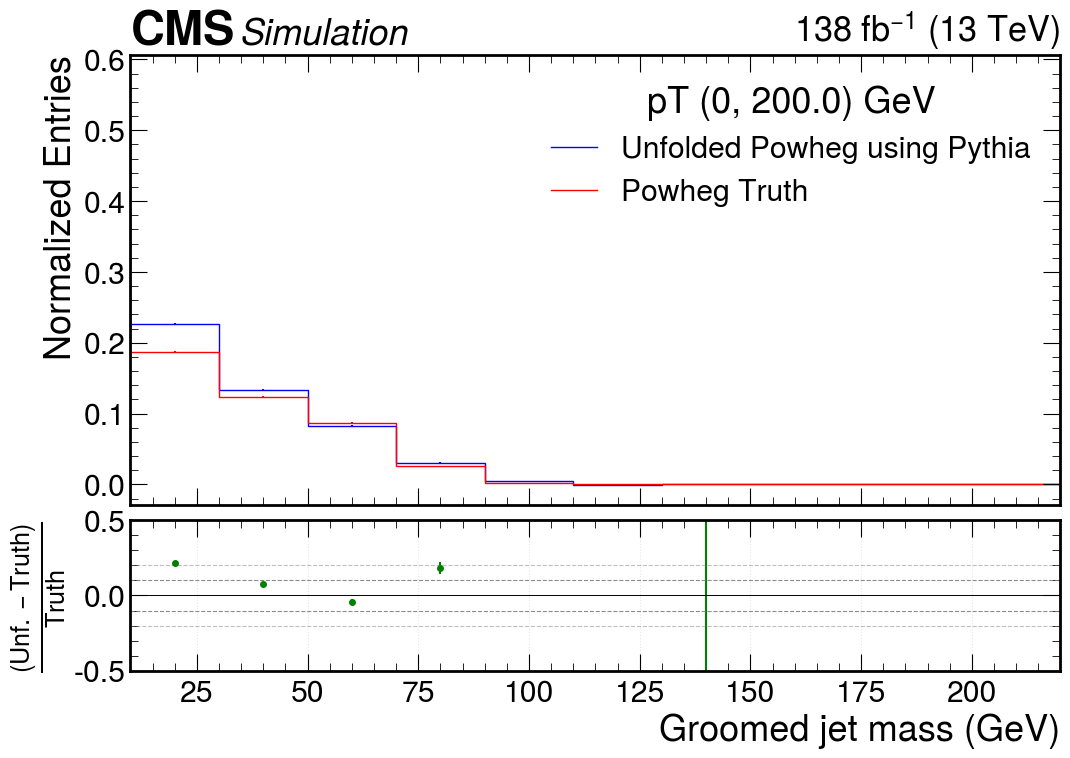

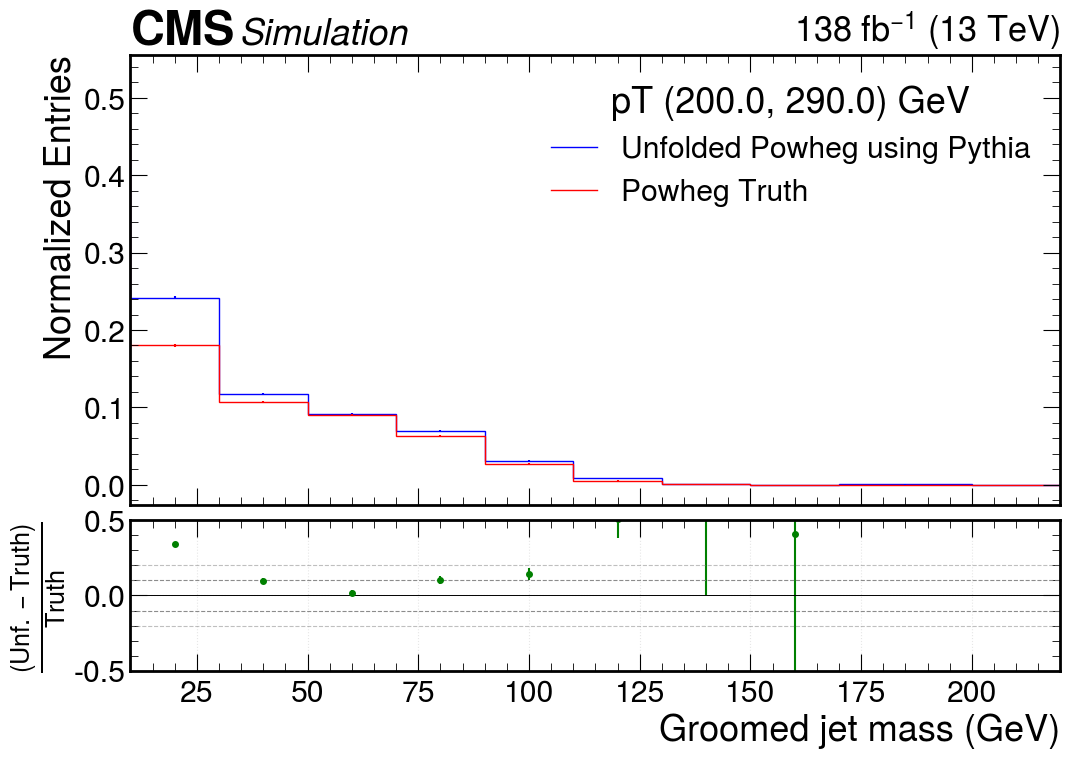

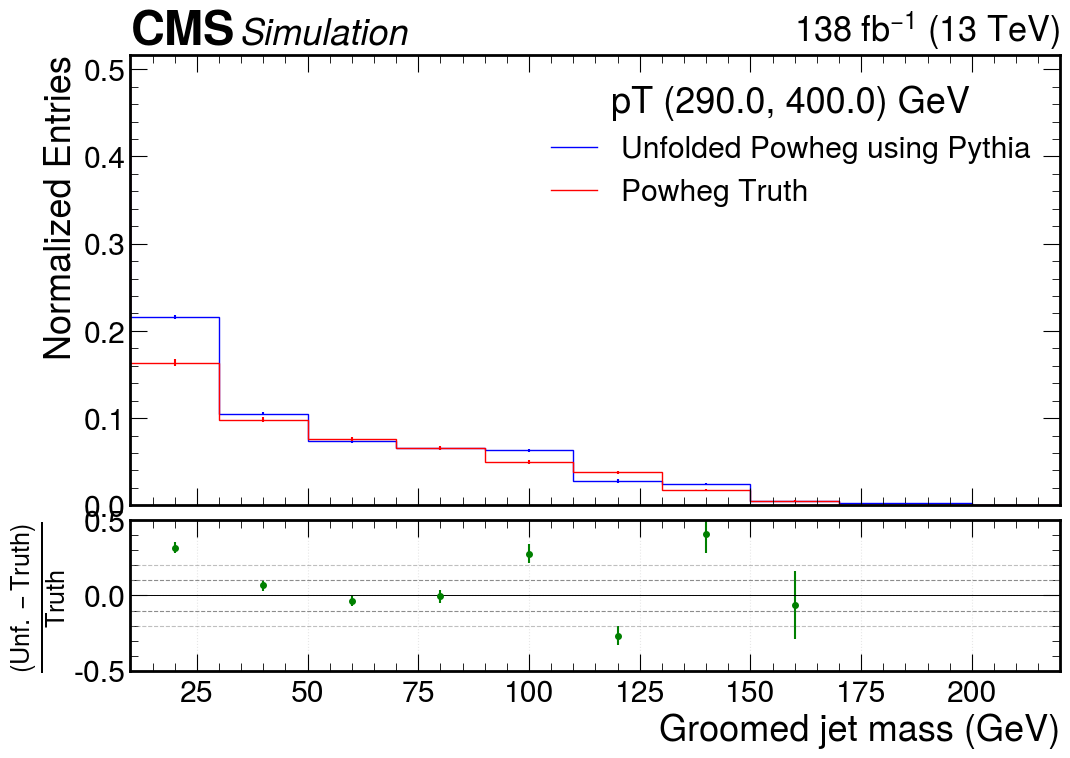

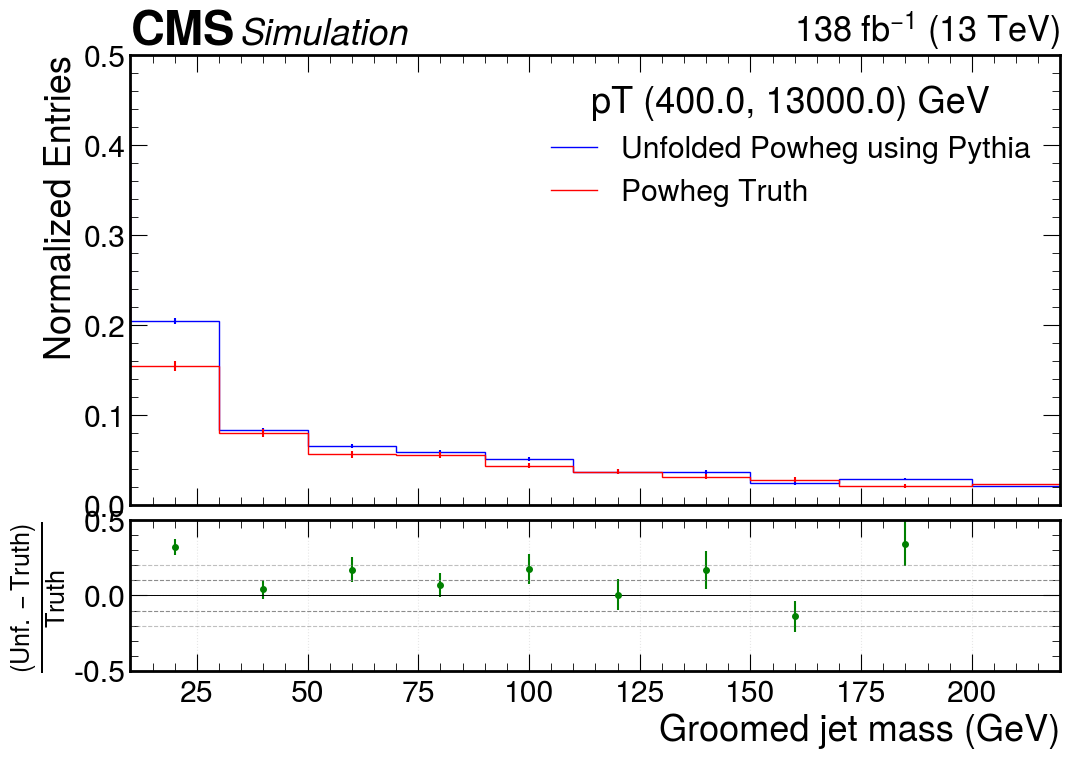

In [ ]:
xlabel = "Groomed jet mass (GeV)" if groomed else "Ungroomed jet mass (GeV)"

for i in range(len(pt_slices)):
    start = i * nbins_m
    end = start + nbins_m

    # unfolded (U) and truth (T) for this pt slice
    U = vals2[start:end].copy()
    Uerr = vals2_err[start:end].copy()
    T = gen_vals2[i][:nbins_m].copy()
    Terr = np.sqrt(gen_vars2_[i][:nbins_m].copy())  # std dev

    edges_i = np.array(mgen_edges_pt[i])
    centers_i = mgen_centres  # already length nbins_m

    fig, (ax, axr) = plt.subplots(2, 1, sharex=True,
                                  gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
                                  figsize=(12, 8))  # increased figure size

    # Top: unfolded vs truth
    ax.stairs(U, edges_i, label="Unfolded Powheg using Pythia", color="b")
    ax.errorbar(centers_i, U, yerr=Uerr, fmt="none", ecolor="b", capsize=0)
    ax.stairs(T, edges_i, label="Powheg Truth", color="r")
    ax.errorbar(centers_i, T, yerr=Terr, fmt="none", ecolor="r", capsize=0)

    ax.set_ylabel("Normalized Entries")
    #ax.set_title("Unfolded vs Truth")  # removed pt slice from title
    ax.legend(title=f"pT {pt_slices[i]} GeV")  # put slice info into legend title
    ax.set_xlim(10, 220)  # end at 220


    # add CMS label
    hep.cms.label(ax=ax, data=False, lumi=138)

    # Bottom: ratio (U - T) / T with propagated errors (avoid divide-by-zero)
    mask = T != 0
    ratio = np.full_like(U, np.nan, dtype=float)
    ratio_err = np.full_like(U, np.nan, dtype=float)

    ratio[mask] = (U[mask] - T[mask]) / T[mask]
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio_err[mask] = np.sqrt(
            (Uerr[mask] ** 2) / (T[mask] ** 2)
            + (gen_vars2_[i][:nbins_m][mask] * (U[mask] ** 2)) / (T[mask] ** 4)
        )

    axr.errorbar(centers_i, ratio, yerr=ratio_err, fmt="o", markersize=4, color="g", capsize=0)
    axr.axhline(0.0, color="k", lw=0.7)
    axr.axhline(-0.1, color="gray", linestyle="--", lw=0.8, alpha=0.9)
    axr.axhline(0.1, color="gray", linestyle="--", lw=0.8, alpha=0.9)
    axr.axhline(-0.2, color="gray", linestyle="--", lw=0.8, alpha=0.5)
    axr.axhline(0.2, color="gray", linestyle="--", lw=0.8, alpha=0.5)
    axr.set_ylabel(r"$\frac{(Unf.-Truth)}{Truth}$")
    axr.set_xlabel(xlabel)
    
    axr.set_ylim(-0.5, 0.5)
    axr.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


In [64]:
# use TH1::Clone to duplicate (provide a new name)
output_rebinned = output.Clone("output_rebinned")
y_rebinned = y.Clone("y_rebinned")
y_rebinned.Rebin(2)
output_rebinned.Rebin(2)
c3 = r.TCanvas('c3','c3',800,600)
output_rebinned.SetLineColor(r.kRed)
output_rebinned.Draw('E')
y_rebinned.Draw('same')
c3.Draw()

In [127]:
rebin_factors = [ 5, 10]
loaded_outputs = {}
for rf in rebin_factors:
    with np.load(f"herwig_output_{rf}.npz") as data:
        loaded_outputs[rf] = {key: data[key] for key in data.files}

fig, ax = plt.subplots(figsize=(8, 5))
for rf in rebin_factors:
    unfolded = loaded_outputs[rf]["unfolded"]
    unfolded_err = loaded_outputs[rf]["unfolded_err"]
    bins = np.arange(len(unfolded))
    ax.errorbar(
        bins,
        unfolded,
        yerr=unfolded_err,
        label=f"Herwig rebin {rf}",
        marker="o",
        linestyle="-",
        capsize=2,
    )

ax.set_xlabel("Unfolded bin")
ax.set_ylabel("Entries")
ax.set_title("Herwig unfolded comparison")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()


FileNotFoundError: [Errno 2] No such file or directory: 'herwig_output_10.npz'